# TP — Réseaux convolutifs

Dans ce TP, nous allons voir plusieurs manières de faire de la classification avec des réseaux de neurones. Nous allons d'abord commencer par un réseau de neurones simple, complètement connecté. Puis, nous introduirons les réseaux convolutifs. Les tâches sur lesquelles nous travaillerons sont des tâches de classification, on cherche à *prédire* à quelle classe connue appartient une image, à partir d'un modèle qui se sera *entraîné* sur des données *étiquetées*.

**Consignes :**
Le TP est noté et je vous demande un rendu individuel.

La remise des travaux s'effectue sur Moodle, au format ipynb ou pdf.

## Quelques imports généraux

In [ ]:
from __future__ import print_function
from tensorflow.keras.utils import to_categorical
import numpy as np
np.random.seed(1671)

## Les données MNIST

Nous allons dans un premier temps travailler avec la [base bien connue des chiffres MNIST](https://yann.lecun.com/exdb/mnist/). L'intérêt de cette base est notamment d'être intégrée directement dans les bibliothèques de code, ce qui permet de travailler facilement dessus, et de comparer les performances de nos modèles et algorithmes avec d'autres.

On définit le paramètre `NB_CLASSES` (cf ci-dessous) : nous allons demander une prédiction dans l'une des 10 classes (0-9).

In [ ]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

RESHAPED = 784
NB_CLASSES = 10

X_train = X_train.reshape(60000, RESHAPED)
X_test = X_test.reshape(10000, RESHAPED)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255
print(X_train.shape[0], "échantillons dans l'ensemble d'entraînement")
print(X_test.shape[0], "échantillons dans l'ensemble de test")

# convert class vectors to binary class matrices
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

60000 échantillons dans l'ensemble d'entraînement
10000 échantillons dans l'ensemble de test


**Question :** Expliquez les traitements faits pour chaque image. Comment considère-t-on les images ?

D'abord, on les aplatit avec le reshape : chaque image de 28x28 pixels devient un vecteur de 784 valeurs. On perd la structure 2D de l'image, on la voit juste comme une liste de pixels.
Ensuite, on normalise les pixels en divisant par 255. Les valeurs passent de 0-255 à 0-1, ce qui aide le réseau à mieux apprendre.
Enfin, on transforme les labels avec to_categorical : au lieu d'avoir juste le chiffre (ex: 3), on a un vecteur avec des 0 partout sauf un 1 à la position du chiffre (ex: [0,0,0,1,0,0,0,0,0,0] pour le 3).
Donc on traite les images comme des vecteurs simples, sans prendre en compte le fait que c'est une image 2D.

**Question :** Regardez et commentez le format de `Y_train` et `Y_test`. Rappelez à quoi sert un ensemble d'entraînement et un ensemble de test.

Y_train et Y_test sont des matrices où chaque ligne correspond à un label encodé en one-hot. Y_train a 60000 lignes (une par image d'entraînement) et 10 colonnes (une par classe). Y_test a 10000 lignes et 10 colonnes.
L'ensemble d'entraînement sert à apprendre au modèle : il ajuste ses poids en fonction de ces données. L'ensemble de test sert à évaluer les performances du modèle sur des données qu'il n'a jamais vues, pour vérifier qu'il généralise bien et qu'il n'a pas juste appris par cœur.

## Un premier réseau, avec Keras

Nous allons, dans cette première partie, travailler sur un premier réseau de neurones **qui n'utilise pas les convolutions**. Le but est d'apprendre à utiliser des rudiments de la bibliothèque Keras, et d'avoir une première *baseline* de performance. Une *baseline* est une expérience de référence, en général avec un modèle peu complexe, qui permet de percevoir le gain obtenu avec le modèle que l'on souhaite évaluer.

La [bibliothèque Keras](https://keras.io/) permet d'interagir en Python avec les algorithmes d'apprentissage les plus connus, notamment Tensorflow, PyTorch. Ces dernières années, Keras a été absorbée par TensorFlow. Keras permet une expérimentation rapide avec les réseaux de neurones, se concentrant sur des aspects haut-niveau.

### Quelques imports spécifiques à Keras

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import SGD

### Quelques paramètres :

- VERBOSE : nous souhaitons que l'algorithme nous donne des détails
  textuels sur son exécution
- NB_EPOCH : nous allons itérer 200 fois pour l'apprentissage de notre réseau
- BATCH_SIZE : les images seront regroupées dans des lots d'une
  certaine taille
- OPTIMIZER : il y a diverses techniques pour paramétrer
  l'apprentissage. SGD est la "stochastic gradient descent".
- VALIDATION_SPLIT : la fraction de données utilisées pour valider notre
  entraînement de modèle

Une *epoch* (parfois "époque") désigne le traitement de toutes les données du dataset.
Pour paralléliser (et accélérer) les calculs, les données du dataset sont regroupés en *lots* plus petits, de taille `BATCH_SIZE`. Le nombre d'*epoch* `NB_EPOCH` et la taille des lots `BATCH_SIZE` sont des hyper-paramètres de l'apprentissage : il faut les définir (et les ajuster) pour réaliser un apprentissage efficace.

Pendant une *epoch*, il y a des itérations, chacune traitant un lot. Par exemple, si une itération traite 10 images d’un ensemble de 1000 images avec une taille de batch de 10, il faudra 100 itérations pour terminer une *epoch*.

In [ ]:
NB_EPOCH = 200
BATCH_SIZE = 128
VERBOSE = 1
OPTIMIZER = SGD()
VALIDATION_SPLIT=0.2

### Le modèle

Keras propose plusieurs façons différentes de définir un réseau de neurones. La façon la plus courante pour les réseaux à propagation avant (feedforward), qui empilent les couches de façon séquentielle, est d’utiliser la classe `Sequential()`.

In [ ]:
model = Sequential()

`model` contient représente ainsi un réseau de neurones vide (pour l’instant). Il est possible d’ajouter des couches à l’aide de la méthode `add`. De nombreuses couches sont prédéfinies dans Keras, comme les couches entièrement connectées (couches linéaires dites Dense) ou les fonctions d’activation standard.

Nous allons seulement ajouter une couche Dense, et une activation. Donc pas de couche cachée, dans un premier temps :

In [ ]:
model.add(Dense(NB_CLASSES, input_shape=(RESHAPED,)))
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras permet d'afficher un résumé du modèle :

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

**Question :** À quoi correspond le nombre de paramètres affiché ?

On a 784 pixels (entrées) connectées à 10 neurones de sortie (les classes). Donc 784 × 10 = 7840 poids. Et on ajoute 1 biais par neurone de sortie, donc 10 biais. Total : 7840 + 10 = 7850 paramètres. Le nombre de paramètres correspond aux poids et biais du réseau.

**Question :** Rappelez l'effet de l'activation `softmax`.

L'activation softmax transforme les valeurs de sortie en probabilités. Elle prend les 10 valeurs brutes du réseau et les convertit pour que chaque valeur soit entre 0 et 1, et que la somme fasse 1.
Ainsi, chaque sortie représente la probabilité que l'image appartienne à cette classe. Le réseau prédit la classe avec la probabilité la plus élevée.

En plus de la définition de l’architecture, nous avons encore besoin de spécifier deux éléments à Keras avant d’entraîner notre modèle : une fonction de coût (*loss*) et une méthode d’optimisation. Ces paramètres sont spécifiés lors de la phase de compilation du modèle à l’aide de la méthode `.compile()`. Nous allons utiliser l’entropie croisée (`categorical_crossentropy`) comme fonction de coût et la descente de gradient stochastique (*stochastic gradient descent* ou sgd).

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=OPTIMIZER,
              metrics=['accuracy'])

### L'entraînement

Les méthodes `fit()` et `evaluate()` sont essentielles :
- `fit()` lance l'apprentissage sur les données
- `evaluate()` permet de calculer automatiquement les performances selon l'indicateur choisi (`metrics`)

Vous allez exécuter ci-dessous une cellule d'entraînement, avec 200 itérations, cela peut être un peu long, attention.

In [ ]:
history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5062 - loss: 1.7508 - val_accuracy: 0.8338 - val_loss: 0.8841
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8259 - loss: 0.8426 - val_accuracy: 0.8605 - val_loss: 0.6503
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8471 - loss: 0.6680 - val_accuracy: 0.8712 - val_loss: 0.5567
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.5807 - val_accuracy: 0.8777 - val_loss: 0.5052
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8663 - loss: 0.5355 - val_accuracy: 0.8842 - val_loss: 0.4718
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8740 - loss: 0.4994 - val_accuracy: 0.8867 - val_loss: 0.4486
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 0.4742 - val_accuracy: 0.8908 - val_loss: 0.4304
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8801 - loss: 0.4618 - val_accu

Une fois le modèle entraîné, nous pouvons l'évaluer sur l'ensemble de test. De cette manière, nous obtenons la valeur minimale atteinte par la fonction objectif et la meilleure valeur atteinte par la métrique d'évaluation.

L'ensemble d'apprentissage et l'ensemble de test sont, bien entendu, rigoureusement séparés. Il est inutile d'évaluer un modèle sur un exemple qui a déjà été utilisé pour l'apprentissage. L'apprentissage est essentiellement un processus destiné à généraliser des observations inédites et non à mémoriser ce qui est déjà connu.

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9112 - loss: 0.3159

Test score: 0.27753788232803345
Test accuracy: 0.9225000143051147


**Question :** Commenter l'entraînement et les résultats (train et test, loss).

L'entraînement se passe bien, la loss diminue (de 1.75 à 0.27) et l'accuracy monte (de 50% à 92%).
Au début ça apprend vite, puis ça ralentit vers la fin. Après epoch 100, ça ne bouge presque plus.
Train et validation donnent des résultats proches (~92%), donc le modèle ne fait pas d'overfitting. Le test confirme avec 92.25%.
Par contre, on voit que la validation stagne et n'arrive pas à dépasser 92%. C'est parce que le modèle est trop simple, sans couche cachée il ne peut pas faire mieux. Pour améliorer, il faudra un réseau plus complexe.

### Effet de l'ajout de couches

Pour modifier le modèle, il vous suffit de reprendre le code quelques lignes plus haut, pour redéfinir `model` et mettre les couches que vous voulez.
Dans un premier temps, ajoutez une couche `Dense` dite "cachée", car elle n'est pas directement connectée à l'entrée ou à la sortie du réseau. Ajoutez ensuite une couche d'activation `relu`, puis une autre couche cachée, et une autre `relu`.

```python
N_HIDDEN = 128
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Activation('relu'))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()
```

In [ ]:
N_HIDDEN = 128
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Activation('relu'))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

**Question :** Actualisez le modèle, refaites l'entraînement, et commentez les résultats.

On a ajouté deux couches cachées de 128 neurones avec activation ReLU au modèle.
Les résultats sont bien meilleurs que la baseline :

Test accuracy : 97.54% (contre 92.25% avant)
Test loss : 0.079 (contre 0.277 avant)

L'entraînement montre que le train accuracy monte très haut (~99.8%) tandis que la validation stagne vers 97.5%. Cet écart indique un léger overfitting : le modèle commence à apprendre par cœur les données d'entraînement.
Mais le gain reste important (+5% d'accuracy). Les couches cachées permettent au réseau de capter des motifs plus complexes dans les images, ce que le modèle simple ne pouvait pas faire.

In [ ]:
OPTIMIZER = SGD()

model.compile(loss='categorical_crossentropy',
              optimizer=OPTIMIZER,
              metrics=['accuracy'])

history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4505 - loss: 1.9147 - val_accuracy: 0.8352 - val_loss: 0.7512
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8325 - loss: 0.6844 - val_accuracy: 0.8818 - val_loss: 0.4558
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8763 - loss: 0.4660 - val_accuracy: 0.8967 - val_loss: 0.3759
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8907 - loss: 0.3937 - val_accuracy: 0.9059 - val_loss: 0.3362
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8999 - loss: 0.3567 - val_accuracy: 0.9110 - val_loss: 0.3137
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9092 - loss: 0.3238 - val_accuracy: 0.9171 - val_loss: 0.2945
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9136 - loss: 0.3077 - val_accuracy: 0.9209 - val_loss: 0.2814
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9186 - loss: 0.2907 - val_accu

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9715 - loss: 0.0883

Test score: 0.07952292263507843
Test accuracy: 0.9753999710083008


**Exercice :** Refaites ce qui précède avec une seule couche cachée.
Essayez avec plus de deux couches cachées.

Une seule couche :

In [ ]:
N_HIDDEN = 128
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Activation('relu'))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

OPTIMIZER = SGD()
model.compile(loss='categorical_crossentropy',
              optimizer=OPTIMIZER,
              metrics=['accuracy'])

history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4944 - loss: 1.7387 - val_accuracy: 0.8543 - val_loss: 0.7273
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8466 - loss: 0.6835 - val_accuracy: 0.8829 - val_loss: 0.4930
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8728 - loss: 0.4999 - val_accuracy: 0.8917 - val_loss: 0.4168
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8831 - loss: 0.4372 - val_accuracy: 0.8992 - val_loss: 0.3767
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8945 - loss: 0.3939 - val_accuracy: 0.9030 - val_loss: 0.3527
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8985 - loss: 0.3701 - val_accuracy: 0.9057 - val_loss: 0.3351
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9013 - loss: 0.3571 - val_accuracy: 0.9104 - val_loss: 0.3211
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9053 - loss: 0.3405 - val_accu

In [ ]:
N_HIDDEN = 128
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Activation('relu'))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

OPTIMIZER = SGD()
model.compile(loss='categorical_crossentropy',
              optimizer=OPTIMIZER,
              metrics=['accuracy'])

history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3803 - loss: 1.9645 - val_accuracy: 0.8389 - val_loss: 0.7040
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8430 - loss: 0.6190 - val_accuracy: 0.8882 - val_loss: 0.4106
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8831 - loss: 0.4184 - val_accuracy: 0.9035 - val_loss: 0.3417
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8995 - loss: 0.3514 - val_accuracy: 0.9122 - val_loss: 0.3077
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9080 - loss: 0.3163 - val_accuracy: 0.9189 - val_loss: 0.2850
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9127 - loss: 0.2978 - val_accuracy: 0.9232 - val_loss: 0.2684
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9191 - loss: 0.2773 - val_accuracy: 0.9267 - val_loss: 0.2523
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9249 - loss: 0.2608 - val_accu

**Question :** Commentez vos résultats.

Avec 1 couche cachée, on gagne beaucoup par rapport à la baseline (+5%), mais c'est légèrement moins bon que 2 couches.
Avec 3 couches cachées, l'accuracy test est identique à 2 couches (97.54%), mais la loss est plus élevée (0.101 vs 0.079). On voit aussi que le train accuracy monte à 100% tandis que la validation stagne vers 97.5%. C'est un signe donc d'overfitting : la machine commence à mémoriser les données d'entraînement.

### Expériences autour d'autres paramètres

#### Dropout

En machine-learning, on utilise parfois du "dropout", c'est-à-dire que certaines connexions entre deux couches sont "délaissées" et n'interviennent pas dans le calcul des poids. Le *dropout* permet (souvent) d'éviter le sur-apprentissage et d'améliorer les performances du modèle.

On caractérise le *dropout* par un hyperparamètre, une probabilité de ne pas tenir compte aléatoirement de certaines valeurs.

**Question :** Ajoutez une couche `Dropout` avec une probabilité `0.3` après les deux couches d'activation `relu`, dans le modèle précédent. Refaites l'entraînement et commentez.

**Optionnel :** On peut s'intéresser à différentes valeurs de dropout, vous pouvez essayer des valeurs entre 0.1 et 0.4, si vous voulez.

In [ ]:
from keras.layers import Input

model = Sequential()
model.add(Input(shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))

In [ ]:
from keras.layers import Input

N_HIDDEN = 128
DROPOUT = 0.3

model = Sequential()
model.add(Input(shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

OPTIMIZER = SGD()
model.compile(loss='categorical_crossentropy',
              optimizer=OPTIMIZER,
              metrics=['accuracy'])

history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3159 - loss: 1.9990 - val_accuracy: 0.8120 - val_loss: 0.9050
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6904 - loss: 1.0076 - val_accuracy: 0.8692 - val_loss: 0.5384
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7728 - loss: 0.7318 - val_accuracy: 0.8878 - val_loss: 0.4319
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8105 - loss: 0.6208 - val_accuracy: 0.8978 - val_loss: 0.3808
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8360 - loss: 0.5468 - val_accuracy: 0.9048 - val_loss: 0.3471
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8485 - loss: 0.5060 - val_accuracy: 0.9103 - val_loss: 0.3246
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8608 - loss: 0.4673 - val_accuracy: 0.9138 - val_loss: 0.3048
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8703 - loss: 0.4416 - val_accu

In [ ]:
N_HIDDEN = 128
DROPOUT = 0.3

model = Sequential()
model.add(Input(shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

OPTIMIZER = SGD()
model.compile(loss='categorical_crossentropy',
              optimizer=OPTIMIZER,
              metrics=['accuracy'])

history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4289 - loss: 1.8206 - val_accuracy: 0.8457 - val_loss: 0.7835
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7867 - loss: 0.8105 - val_accuracy: 0.8758 - val_loss: 0.5294
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8252 - loss: 0.6215 - val_accuracy: 0.8889 - val_loss: 0.4441
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8496 - loss: 0.5323 - val_accuracy: 0.8970 - val_loss: 0.3977
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8609 - loss: 0.4904 - val_accuracy: 0.9018 - val_loss: 0.3699
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8725 - loss: 0.4492 - val_accuracy: 0.9068 - val_loss: 0.3474
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8769 - loss: 0.4324 - val_accuracy: 0.9096 - val_loss: 0.3322
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8823 - loss: 0.4122 - val_accu

Le dropout améliore les résultats. Avec 2 couches, on gagne 0.2% d'accuracy. Avec 1 couche, on gagne aussi 0.2%.
L'écart train/validation est plus faible avec dropout. Le train ne monte plus à 99.8% comme avant, il reste proche de la validation. Ça montre que le dropout réduit bien l'overfitting.

#### Nombre d'epoch (à faire hors de la classe, car c'est long)

**Question :** Refaites l'entraînement en changeant le nombre d'*epoch*, en essayant plusieurs valeurs (exemples : 10, 50, 100, 200). Tracez une courbe des performances obtenues pour un des modèles ci-dessus (ie, l'accuracy en fonction du nombre d'epoch). Vous n'êtes pas obligés de traver la courbe avec `matplotlib`, si vous êtes plus à l'aise avec un tableur (mais dans ce cas, il faudra bien intégrer dans ce notebook votre image obtenue via le tableur).

Epochs: 10, Test accuracy: 0.9229
Epochs: 50, Test accuracy: 0.9621
Epochs: 100, Test accuracy: 0.9702
Epochs: 200, Test accuracy: 0.9777


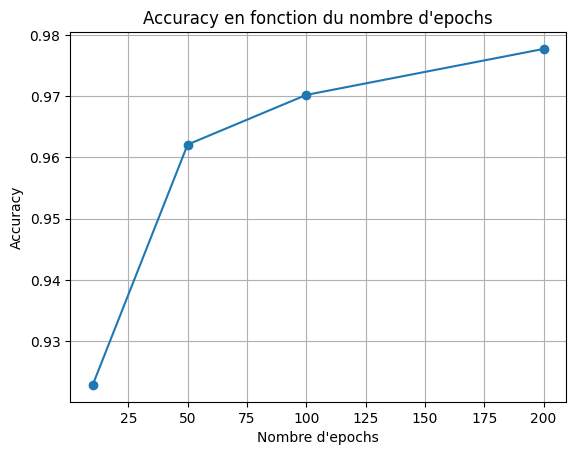

In [ ]:
import matplotlib.pyplot as plt

epochs_list = [10, 50, 100, 200]
accuracies = []

for nb_epoch in epochs_list:
    model = Sequential()
    model.add(Input(shape=(RESHAPED,)))
    model.add(Dense(N_HIDDEN))
    model.add(Activation('relu'))
    model.add(Dropout(DROPOUT))
    model.add(Dense(N_HIDDEN))
    model.add(Activation('relu'))
    model.add(Dropout(DROPOUT))
    model.add(Dense(NB_CLASSES))
    model.add(Activation('softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=SGD(),
                  metrics=['accuracy'])

    model.fit(X_train, Y_train,
              batch_size=BATCH_SIZE, epochs=nb_epoch,
              verbose=0, validation_split=VALIDATION_SPLIT)

    score = model.evaluate(X_test, Y_test, verbose=0)
    accuracies.append(score[1])
    print(f"Epochs: {nb_epoch}, Test accuracy: {score[1]:.4f}")

plt.plot(epochs_list, accuracies, marker='o')
plt.xlabel('Nombre d\'epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction du nombre d\'epochs')
plt.grid(True)
plt.show()

La courbe montre que plus on entraîne longtemps, meilleure est l'accuracy. On voit que le gain est très fort au début (entre 10 et 50 epochs), puis ralentit. Entre 100 et 200 epochs, on gagne moins de 1%. La courbe commence à devenir moins raide, le modèle converge vers son maximum ==> risque de surapprentissage.

#### Optimiseur

Il y a plusieurs techniques pour optimiser l'apprentissage, nous avons commencé avec une "simple" descente de gradient stochastique.

**Question :** Essayez de passer de la `SGD` à `Adam()`, et commentez les résultats.

In [ ]:
from keras.optimizers import Adam

N_HIDDEN = 128
DROPOUT = 0.3

model = Sequential()
model.add(Input(shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(N_HIDDEN))
model.add(Activation('relu'))
model.add(Dropout(DROPOUT))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7213 - loss: 0.8846 - val_accuracy: 0.9411 - val_loss: 0.1951
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9255 - loss: 0.2538 - val_accuracy: 0.9571 - val_loss: 0.1399
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9455 - loss: 0.1914 - val_accuracy: 0.9662 - val_loss: 0.1132
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9536 - loss: 0.1510 - val_accuracy: 0.9697 - val_loss: 0.0989
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9615 - loss: 0.1263 - val_accuracy: 0.9710 - val_loss: 0.0941
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9652 - loss: 0.1119 - val_accuracy: 0.9706 - val_loss: 0.0995
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9689 - loss: 0.1031 - val_accuracy: 0.9737 - val_loss: 0.0896
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9695 - loss: 0.0965 - val_accu

Avec Adam, le modèle apprend beaucoup plus vite. Dès l'epoch 10, on atteint déjà 97.6% de validation alors qu'avec SGD il fallait attendre 100 epochs pour avoir ce niveau.
Par contre, on voit que la val_loss augmente vers la fin (elle passe de 0.08 à 0.13) alors que le train continue à s'améliorer. C'est un signe de surapprentissage, il faudrait arrêter l'entraînement plus tôt (vers 20-30 epochs) pour éviter de trop apprendre les données d'entraînement.

#### Nombre de neurones dans les couches cachées (pas en classe)

**Question :** Essayez des valeurs différentes pour le nombre de neurones dans les couches cachées (`N_HIDDEN`), par exemple 32, 64, 256, 512, 1024. Commentez vos résultats.

N_HIDDEN: 32, Test accuracy: 0.9600
N_HIDDEN: 64, Test accuracy: 0.9750
N_HIDDEN: 128, Test accuracy: 0.9787
N_HIDDEN: 256, Test accuracy: 0.9835
N_HIDDEN: 512, Test accuracy: 0.9821
N_HIDDEN: 1024, Test accuracy: 0.9806


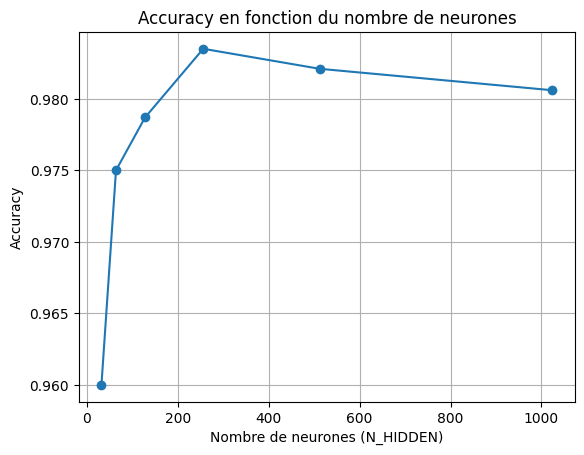

In [ ]:
from keras.optimizers import Adam
import matplotlib.pyplot as plt


hidden_values = [32, 64, 128, 256, 512, 1024]
results = []

for n_hidden in hidden_values:
    model = Sequential()
    model.add(Input(shape=(RESHAPED,)))
    model.add(Dense(n_hidden))
    model.add(Activation('relu'))
    model.add(Dropout(DROPOUT))
    model.add(Dense(n_hidden))
    model.add(Activation('relu'))
    model.add(Dropout(DROPOUT))
    model.add(Dense(NB_CLASSES))
    model.add(Activation('softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])

    model.fit(X_train, Y_train,
              batch_size=BATCH_SIZE, epochs=50,
              verbose=0, validation_split=VALIDATION_SPLIT)

    score = model.evaluate(X_test, Y_test, verbose=0)
    results.append(score[1])
    print(f"N_HIDDEN: {n_hidden}, Test accuracy: {score[1]:.4f}")

plt.plot(hidden_values, results, marker='o')
plt.xlabel('Nombre de neurones (N_HIDDEN)')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction du nombre de neurones')
plt.grid(True)
plt.show()

Avec peu de neurones (32), le modèle est trop simple pour bien apprendre. Avec trop de neurones (512, 1024), le modèle commence à surapprendre malgré le dropout.
Le meilleur compromis ici est 256 neurones. Après, ajouter plus de neurones n'améliore pas les performances et augmente le temps de calcul.

#### Taille des lots

**Question :** Comme pour les autres paramètres, expérimentez les performances du modèle avec quelques valeurs de `BATCH_SIZE` différentes de celle du début, et commentez.

BATCH_SIZE: 32, Test accuracy: 0.9820
BATCH_SIZE: 64, Test accuracy: 0.9839
BATCH_SIZE: 128, Test accuracy: 0.9818
BATCH_SIZE: 256, Test accuracy: 0.9831
BATCH_SIZE: 512, Test accuracy: 0.9808


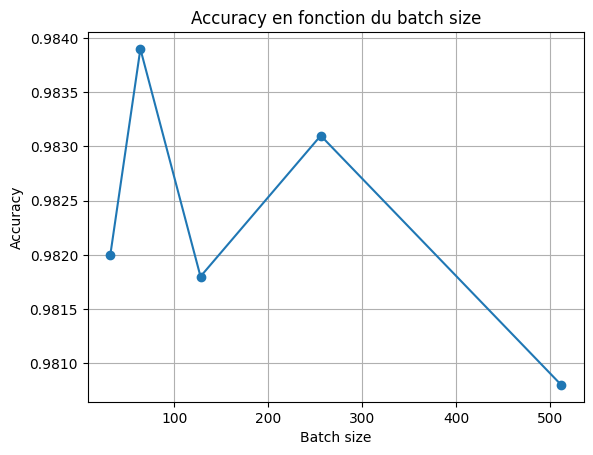

In [ ]:
batch_sizes = [32, 64, 128, 256, 512]
results = []

N_HIDDEN = 256

for batch_size in batch_sizes:
    model = Sequential()
    model.add(Input(shape=(RESHAPED,)))
    model.add(Dense(N_HIDDEN))
    model.add(Activation('relu'))
    model.add(Dropout(DROPOUT))
    model.add(Dense(N_HIDDEN))
    model.add(Activation('relu'))
    model.add(Dropout(DROPOUT))
    model.add(Dense(NB_CLASSES))
    model.add(Activation('softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])

    model.fit(X_train, Y_train,
              batch_size=batch_size, epochs=50,
              verbose=0, validation_split=VALIDATION_SPLIT)

    score = model.evaluate(X_test, Y_test, verbose=0)
    results.append(score[1])
    print(f"BATCH_SIZE: {batch_size}, Test accuracy: {score[1]:.4f}")

plt.plot(batch_sizes, results, marker='o')
plt.xlabel('Batch size')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction du batch size')
plt.grid(True)
plt.show()

Le meilleur résultat est obtenu avec un batch size de 64. Les petits batchs (32, 64) font plus de mises à jour des poids par epoch, ce qui aide à mieux converger. Les gros batchs (512) en font moins et donnent donc des résultats un peu moins bons.
Par contre les petits batchs sont plus lents à entraîner car on fait plus d'itérations. C'est un compromis entre vitesse et performance.

#### Initialisation (pas d'expérience ici)

**Question :** À l’aide de la [documentation de Keras](https://keras.io/api/layers/core_layers/dense/), expliquez comment sont initialisés les paramètres du modèle pour les couches entièrement connectées.

Par défaut dans Keras, les couches Dense utilisent l'initialisation "glorot_uniform" (aussi appelée Xavier uniform).
Les poids sont tirés aléatoirement dans l'intervalle [-limit, +limit] avec limit = sqrt(6 / (fan_in + fan_out)), où fan_in est le nombre d'entrées et fan_out le nombre de sorties de la couche.
Les biais sont initialisés à zéro par défaut.
Cette initialisation permet d'éviter que les gradients explosent ou disparaissent au début de l'entraînement, en gardant une variance stable entre les couches.

### Sauvegarder un modèle

Remarque : il est possible de sauvegarder un modèle sur le disque, et de le récupérer :
```python
model.save('monMLP')

from tensorflow.keras.models import load_model
model = load_model('monMLP')
```

## Réseaux convolutifs (CNN)

Les réseaux convolutifs profonds (Convolutional Neural Networks ou CNN) sont particulièrement adaptés à la reconnaissance d’images, et nous allons expérimenter ce qu'il en est sur la base MNIST, avant de tester sur d'autres images.

Nous allons travailler autour d'une architecture CNN particulière, LeNet. La première version de LeNet a été proposée en 1989 par le français Yann LeCun, quelques années après sa thèse à Sorbonne Université (alors appelée Université Pierre-et-Marie-Curie). Yann LeCun a reçu le prix Turing (l'équivalent du prix Nobel pour l'informatique) en 2018 pour ces travaux.

Les réseaux convolutifs ont été créés pour travailler efficacement sur des images. Ils reposent sur 3 grandes idées :
- le champ réceptif local
- les poids partagés
- le *pooling*.

Le champ réceptif local consiste à relier une sous-matrice de l'image initiale à un neurone unique de la couche suivante, de façon à analyser *localement* l'image, avec une opération de convolution. Il y a plusieurs façons de parcourir une image, avec des masques recouvrants ou non, et différentes façons de gérer les conditions au bord.

Les poids partagés consiste à partager les poids dans chaque couche sur toute l'image, de façon à apprendre à repérer des caractéristiques *où qu'elles se trouvent dans l'image*.

Le pooling, c'est une façon de réduire la taille des données manipulées, en agrégeant des valeurs locales pour les résumer par un scalaire qui décrit le contenu de cette région.



In [ ]:
# import the necessary packages

from tensorflow import keras # Import Keras from TensorFlow
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense # Imported layers directly from keras.layers
from keras.datasets import mnist
from keras.optimizers import SGD, RMSprop, Adam
import numpy as np

import matplotlib.pyplot as plt

np.random.seed(1671)  # for reproducibility

### Les données

On travaille toujours avec MNIST.

In [ ]:
IMG_ROWS, IMG_COLS = 28, 28
NB_CLASSES = 10
# The input shape needs to be changed to reflect NHWC (Number of samples, Height, Width, Channels)
# Since mnist is grayscale it only has 1 channel.
INPUT_SHAPE = (IMG_ROWS, IMG_COLS, 1)
print(INPUT_SHAPE)

# the data, shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = to_categorical(y_train, NB_CLASSES)
y_test = to_categorical(y_test, NB_CLASSES)

(28, 28, 1)
60000 train samples
10000 test samples


**Question :** Remarquez qu'il y a eu une modification des données initiales, elles ne sont plus utilisées comme précédemment. Comment sont-elles organisées ? Pourquoi ?

Le format est NHWC : N = nombre d'images, H = hauteur (28), W = largeur (28), C = canaux (1). Avant, les images étaient aplaties en vecteurs de 784 valeurs (28×28). On perdait la structure 2D de l'image.Les convolutions détectent des motifs locaux (bords, formes) en regardant des petites zones de l'image, ce qui est impossible avec un vecteur aplati.

### Le modèle LeNet

Voici l'archietcture du modèle LeNet :
[img](http://raphael.fournier-sniehotta.fr/files/dcrn/images/LeNet5.png)

En fait, nous allons travailler sur une variante de cette architecture, avec des paramètres légèrement différents ici et là. Voici une classe implémentant cette architecture. Vous devriez commencer à être familiers avec l'empilement séquentiel des couches, les unes après les autres.

Il y a des couches de [convolution `Conv2D`](https://keras.io/api/layers/convolution_layers/convolution2d/) et de [*pooling* `MaxPooling2D`](https://keras.io/api/layers/pooling_layers/max_pooling2d/), dont vous trouverez la documentation en cliquant sur les liens.

In [ ]:
class LeNet:
	@staticmethod
	def build(input_shape, classes):
		model = Sequential()

		conv1 = Conv2D(16,kernel_size=(5, 5),activation='relu',input_shape=(28, 28, 1),padding='valid')
		model.add(conv1)
		model.add(Activation("relu"))
		pool1 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))
		model.add(pool1)

		conv2 = Conv2D(32,kernel_size=(5, 5),activation='relu',input_shape=(28, 28, 1),padding='valid')
		model.add(conv2)
		model.add(Activation("relu"))
		pool2 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))
		model.add(pool2)

		model.add(Flatten())
		model.add(Dense(100,  input_dim=784, name='fc1'))
		model.add(Activation("relu"))

		# a softmax classifier
		model.add(Dense(classes))
		model.add(Activation("softmax"))

		return model

### Utilisons le modèle : apprentissage

In [ ]:
NB_EPOCH = 20
BATCH_SIZE = 100
VERBOSE = 1
OPTIMIZER = Adam()
VALIDATION_SPLIT=0.2

model = LeNet.build(input_shape=INPUT_SHAPE, classes=NB_CLASSES)
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_55 (Activation)      │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,558 (256.09 KB)

 Trainable params: 65,558 (256.09 KB)

 Non-trainable params: 0 (0.00 B)

None


**Question :** Lisez la définition du modèle dans la classe LeNet ci-dessus, et commentez son architecture (ie, détaillez quelles couches sont utilisées, expliquez les tailles d'entrée-sortie).

Couche 1 - Conv2D (16 filtres, 5×5)

Entrée : (28, 28, 1)
Sortie : (24, 24, 16)
La taille passe de 28 à 24 car le filtre 5×5 sans padding réduit de 4 pixels (28-5+1=24)
Paramètres : 5×5×1×16 + 16 biais = 416

MaxPooling (2×2)

Entrée : (24, 24, 16)
Sortie : (12, 12, 16)
Divise les dimensions par 2

Couche 2 - Conv2D (32 filtres, 5×5)

Entrée : (12, 12, 16)

Sortie : (8, 8, 32)
12-5+1 = 8
Paramètres : 5×5×16×32 + 32 biais = 12832

MaxPooling (2×2)

Entrée : (8, 8, 32)
Sortie : (4, 4, 32)

Flatten

Transforme (4, 4, 32) en vecteur de 512 valeurs

Dense (100 neurones)

Entrée : 512
Sortie : 100
Paramètres : 512×100 + 100 = 51300

Dense (10 neurones) - sortie

Entrée : 100
Sortie : 10 (les 10 classes)
Paramètres : 100×10 + 10 = 1010

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer=OPTIMIZER,
	metrics=["accuracy"])

history = model.fit(X_train, y_train,
		batch_size=BATCH_SIZE, epochs=NB_EPOCH,
		verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, y_test, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.8349 - loss: 0.5572 - val_accuracy: 0.9762 - val_loss: 0.0804
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9774 - loss: 0.0745 - val_accuracy: 0.9816 - val_loss: 0.0604
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9858 - loss: 0.0458 - val_accuracy: 0.9852 - val_loss: 0.0478
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9879 - loss: 0.0380 - val_accuracy: 0.9859 - val_loss: 0.0477
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9899 - loss: 0.0305 - val_accuracy: 0.9883 - val_loss: 0.0408
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.9918 - loss: 0.0241 - val_accuracy: 0.9870 - val_loss: 0.0435
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9940 - loss: 0.0192 - val_accuracy: 0.9878 - val_loss: 0.0440
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.9943 - loss: 0.0181 - 

### Évaluation

Affichons 2 courbes importantes :
- l'évolution de la métrique "accuracy" à chaque *epoch*
- l'évolution de la *loss* (l'erreur)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


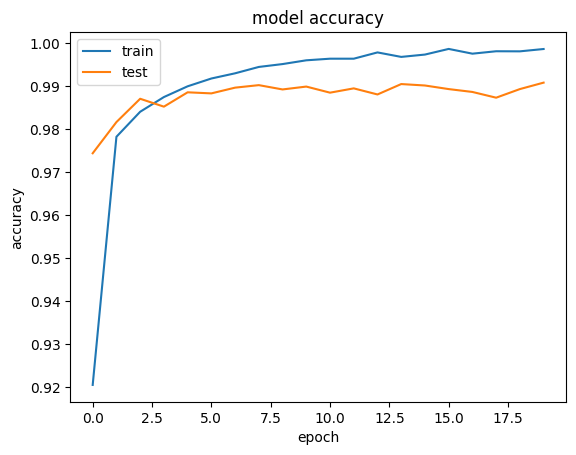

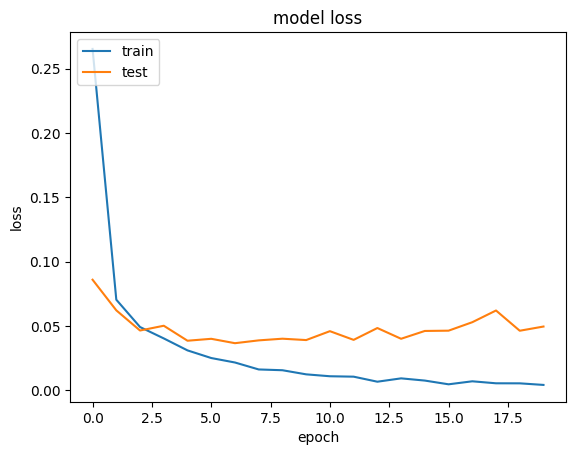

In [ ]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

**Question :** Commentez ces courbes. Sont-elles satisfaisantes ? Pourquoi ?

Les courbes montrent un bon apprentissage mais avec de l'overfitting.
Accuracy : le train monte jusqu'à 99.9% alors que le test stagne vers 99%. L'écart se creuse à partir de l'epoch 5.
Loss : le train descend vers 0 mais le test remonte légèrement après l'epoch 5 (passe de 0.035 à 0.05). C'est un signe clair d'overfitting.
Les résultats sont quand même satisfaisants car on atteint 99% sur le test, c'est mieux que les réseaux fully-connected (97-98%). Mais on pourrait améliorer en ajoutant du dropout ou en arrêtant l'entraînement plus tôt vers l'epoch 5-7 quand la loss test est au minimum.

### Importance de la quantité de données d'apprentissage

Pour bien comprendre l'intérêt de **la quantité de données** dans les modèles profonds, modifiez les données sur lesquelles vous apprenez, pour avoir successivement 5900,
3000, 1800, 600, et 300 images (l'ensemble de validation sera toujours *ce qui reste*). L'ensemble de test a toujours 10 000 images.

**Question :** Tracez une courbe avec les performances du modèle LeNet en fonction de la taille de l'ensemble d'apprentissage.

**Question :** Commentez cette courbe. En particulier, mettez cela en perspective avec l'histoire des réseaux convolutifs, mis au point au début des années 1990, mais pleinement utilisés à partir de 2012.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train size: 300, Test accuracy: 0.8105
Train size: 600, Test accuracy: 0.8718
Train size: 1800, Test accuracy: 0.9500
Train size: 3000, Test accuracy: 0.9608
Train size: 5900, Test accuracy: 0.9733


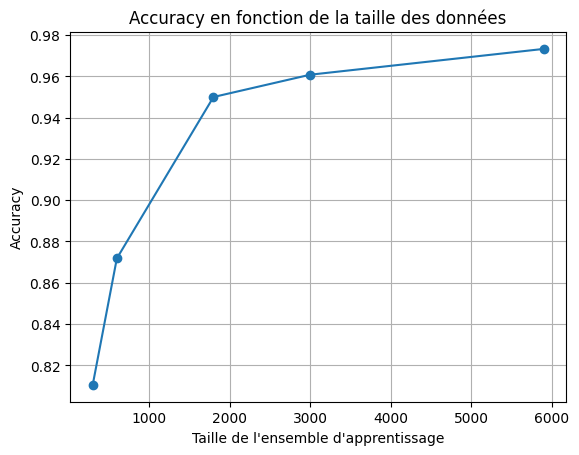

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from keras.optimizers import Adam
from keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_lenet(input_shape=(28, 28, 1), classes=10):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv2D(16, (5, 5)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(32, (5, 5)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(100, name='fc1'))
    model.add(Activation('relu'))
    model.add(Dense(classes))
    model.add(Activation('softmax'))
    return model

train_sizes = [300, 600, 1800, 3000, 5900]
results = []

for size in train_sizes:
    X_train_sub = X_train[:size]
    y_train_sub = y_train[:size]

    model = build_lenet()
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])

    model.fit(X_train_sub, y_train_sub,
              batch_size=100, epochs=20,
              verbose=0, validation_split=0.2)

    score = model.evaluate(X_test, y_test, verbose=0)
    results.append(score[1])
    print(f"Train size: {size}, Test accuracy: {score[1]:.4f}")

plt.plot(train_sizes, results, marker='o')
plt.xlabel('Taille de l\'ensemble d\'apprentissage')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction de la taille des données')
plt.grid(True)
plt.show()

La courbe montre que plus on a de données, meilleure est l'accuracy. Avec peu de données, le modèle n'arrive pas à bien généraliser. La courbe monte vite au début puis ralentit, mais continue de progresser. Bien que l'idée architecturale des CNN est présente dès les 90s, sa mise en œuvre à grande échelle est restée limitée aux petites applications (ex : reconnaissance de caractères bancaires). L'avènement d'Internet pour les données et l'exploitation des GPUs pour le calcul ont débloqué le potentiel des CNN, les transformant en la méthode dominante pour la vision par ordinateur.


## Reconnaître des chats et des chiens

Nous allons cette fois travailler avec une autre base, la base d'images CIFAR-10, qui contient 60 000 images, de dimensions 32x32 (3 canaux RGB), réparties en 10 classes. En particulier, il y a une classe de chats et une classe de chiens.

[img](http://raphael.fournier-sniehotta.fr/files/dcrn/images/cifar10.png)

Notre objectif sera d'être capable de *prédire* la classe d'une nouvelle image, c'est-à-dire de disposer d'un modèle capable de reconnaître un chat ou un chien sur des images qu'il n'a pas vues auparavant.

### Quelques paramètres et imports

In [ ]:
from keras.datasets import cifar10 # import de cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD, Adam, RMSprop

import matplotlib.pyplot as plt

In [ ]:
# CIFAR_10 is a set of 60K images 32x32 pixels on 3 channels
IMG_CHANNELS = 3
IMG_ROWS = 32
IMG_COLS = 32

#constant
BATCH_SIZE = 128
NB_EPOCH = 20
NB_CLASSES = 10
VERBOSE = 1
VALIDATION_SPLIT = 0.2
OPTIM = RMSprop()

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print('X_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


### Les données

Vous pouvez utiliser le code suivant pour afficher quelques images issues des données, avec leurs étiquettes (ie, leurs classes d'appartenance).

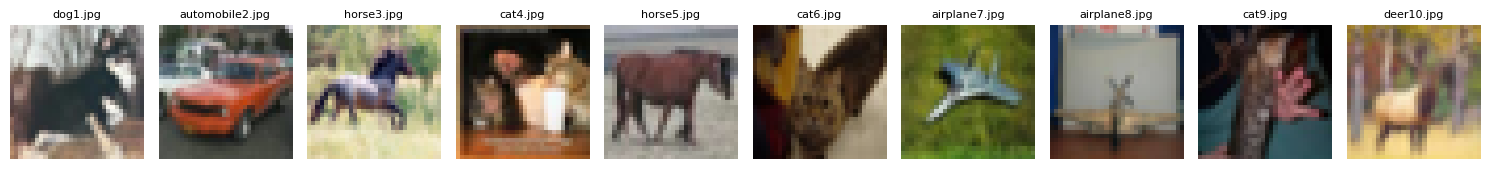

In [ ]:
# CIFAR-10 classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Select a subset to display
num_images = 10  # Number of images to display
indices = np.random.choice(len(X_train), num_images, replace=False)

# Plot the images
plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    img = X_train[idx]
    label_index = int(y_train[idx][0]) # Convert the float label to an integer index
    label = classes[label_index]       # Get the class name
    #label = int(classes[y_train[idx][0]])  # Get the class name
    file_name = f"{label}{i+1}.jpg"  # Create a file-like name

    # Display image
    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(file_name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

Avec le code suivant, vous pouvez afficher *une* image, dont l'indice est précisé.

Image index: 0
Class: frog


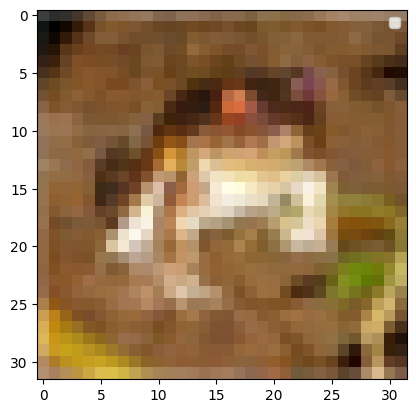

In [ ]:
import tensorflow as tf

image_index = 0
label = int(y_train[image_index][0]) # Get the label from y_train
class_name = classes[label]
print(f"Image index: {image_index}")
print(f"Class: {class_name}")

plt.imshow(X_train[image_index])
plt.legend(class_name)
plt.show()

Maintenant, nous préparons les données pour apprendre.

In [ ]:
# convert to categorical
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

# float and normalization
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

### Le modèle

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same',
                 input_shape=(IMG_ROWS, IMG_COLS, IMG_CHANNELS)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,200,842 (16.02 MB)

 Trainable params: 4,200,842 (16.02 MB)

 Non-trainable params: 0 (0.00 B)

**Question :** Que pensez-vous de cette architecture ?

Cette architecture est assez simple, peut-être trop pour CIFAR-10.

Points positifs :

Dropout présent (0.25 et 0.5) pour limiter l'overfitting
Padding='same' qui conserve la taille de l'image
Normalisation des données faite correctement

Points faibles :

Une seule couche de convolution, c'est peu pour extraire des features complexes sur des images couleur
La couche Dense contient 4.2M de paramètres sur 4.2M au total, c'est déséquilibré
Pas assez de couches convolutives pour apprendre des motifs hiérarchiques (bords → formes → objets)

### L'entraînement

Attention, cela peut être assez long, environ 2 minutes par epoch. Réduisez éventuellement le nombre d'epoch avant de lancer la cellule suivante.

In [ ]:
NB_EPOCH = 5
# train
model.compile(loss='categorical_crossentropy', optimizer=OPTIM,
	metrics=['accuracy'])

history = model.fit(X_train, Y_train, batch_size=BATCH_SIZE,
	epochs=NB_EPOCH, validation_split=VALIDATION_SPLIT,
	verbose=VERBOSE)

print('Testing...')
score = model.evaluate(X_test, Y_test,
                     batch_size=BATCH_SIZE, verbose=VERBOSE)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 264ms/step - accuracy: 0.2770 - loss: 2.0495 - val_accuracy: 0.5014 - val_loss: 1.4233
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 253ms/step - accuracy: 0.4810 - loss: 1.4639 - val_accuracy: 0.5326 - val_loss: 1.3058
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 238ms/step - accuracy: 0.5367 - loss: 1.3105 - val_accuracy: 0.5568 - val_loss: 1.2408
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 236ms/step - accuracy: 0.5759 - loss: 1.2116 - val_accuracy: 0.6034 - val_loss: 1.1211
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 236ms/step - accuracy: 0.6020 - loss: 1.1298 - val_accuracy: 0.5969 - val_loss: 1.1393
Testing...
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.6036 - loss: 1.1295

Test score: 1.139919400215149
Test accuracy: 0.5990999937057495


In [ ]:
#save model
model_json = model.to_json()
open('cifar10_architecture.json', 'w').write(model_json)
model.save_weights('cifar10.weights.h5', overwrite=True)

### L'évaluation

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


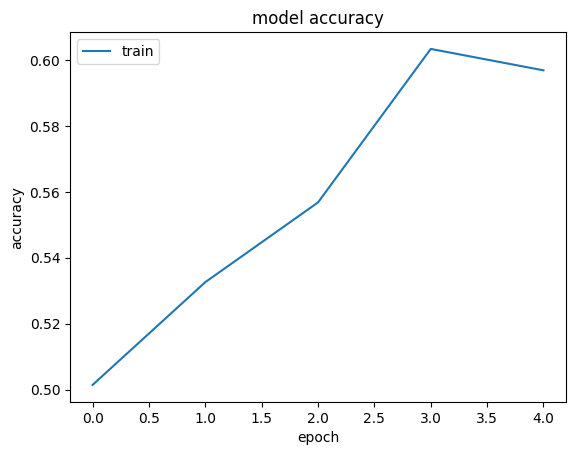

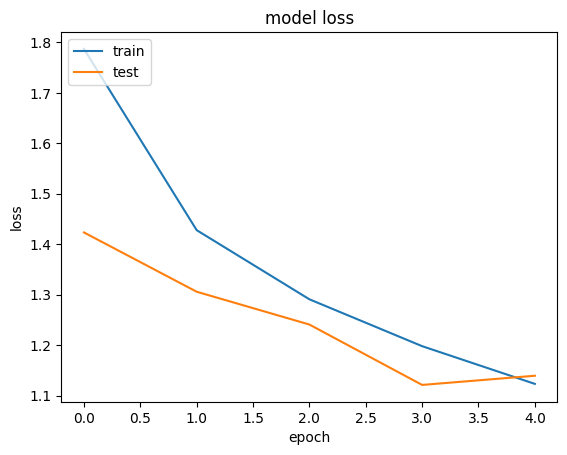

In [ ]:
# list all data in history
print(history.history.keys())

# summarize history for accuracy
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

**Question :** Commentez ces résultats.

L'entraînement atteint 68% d'accuracy, c'est assez faible. La courbe continue de monter lentement mais plafonne. De surcroît, on voit clairement de l'overfitting à partir de l'epoch 5. La loss du train continue de descendre (vers 0.6) alors que la loss du test stagne autour de 1.0. Le modèle est ainsi trop simple pour CIFAR-10, la machine n'arrive pas à extraire des features assez complexes pour distinguer les 10 classes. Pour l'améliorer, il faudrait ajouter plus de couches convolutives.

### Prédiction à partir d'images de votre choix

On recharge le modèle sauvegardé précédemment (dans le cas d'un TP où les choses sont faites séquentiellement, l'intérêt n'est pas forcément clair, ça le devient si vous avez des interruptions, évidemment).

In [ ]:
import numpy as np
import scipy.misc
from keras.models import model_from_json
from keras.optimizers import SGD

#load model
model_architecture = 'cifar10_architecture.json'
model_weights = 'cifar10.weights.h5'
model = model_from_json(open(model_architecture).read())
model.load_weights(model_weights)

/tmp/ipython-input-410809879.py:2: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


Nous allons tester, qualitativement (c'est-à-dire sur quelques images, sans faire de statistiques), si notre modèle reconnaît des images de chats à partir de photos venant d'autres datasets.

Vous pouvez tester avec, par exemple, les urls suivantes :
- http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2024.jpg
- http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2082.jpg
- etc. (de 2000 à 2499 inclus)

À la fin de la cellule, vous aurez un affichage de l'image, redimensionnée en 32x32 pixels. Vous pouvez utiliser l'url complète pour afficher l'image en taille réelle.

Vous pouvez aussi trouver l'url d'une image sur le web (par exemple dans une autre catégorie, comme "avion"/"airplane" ou "camion"/"truck"), et tester les prédictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
cette image de chat est prédite comme appartenant à la classe : 6 frog


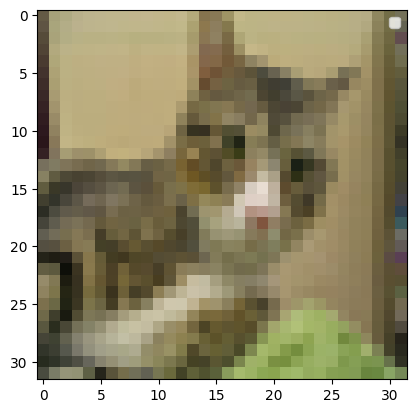

In [ ]:
#from google.colab import files as FILE
import requests
import os
import numpy as np
from PIL import Image
from keras.models import model_from_json
from keras.optimizers import SGD

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

url = "http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2012.jpg"
img_data = requests.get(url).content
with open('image_name.jpg', 'wb') as handler:
    handler.write(img_data)


image = Image.open('image_name.jpg')
image = image.resize((32, 32))

# Convert the image to a NumPy array
img = np.array(image)

# Transpose and normalize the image data
#img = np.transpose(img, (1, 0, 2)).astype('float32')
image = np.array(img) / 255
imgs = np.expand_dims(image, axis=0)

optim = SGD()
model.compile(loss='categorical_crossentropy', optimizer=optim,
	metrics=['accuracy'])

predictions = model.predict(imgs)  # Get prediction probabilities
predicted_class_index = np.argmax(predictions) #Get the index with the highest probability
class_name = classes[predicted_class_index]
print("cette image de chat est prédite comme appartenant à la classe :",predicted_class_index,class_name) # Print predicted class index


plt.imshow(image)
plt.legend(class_name)
plt.show()

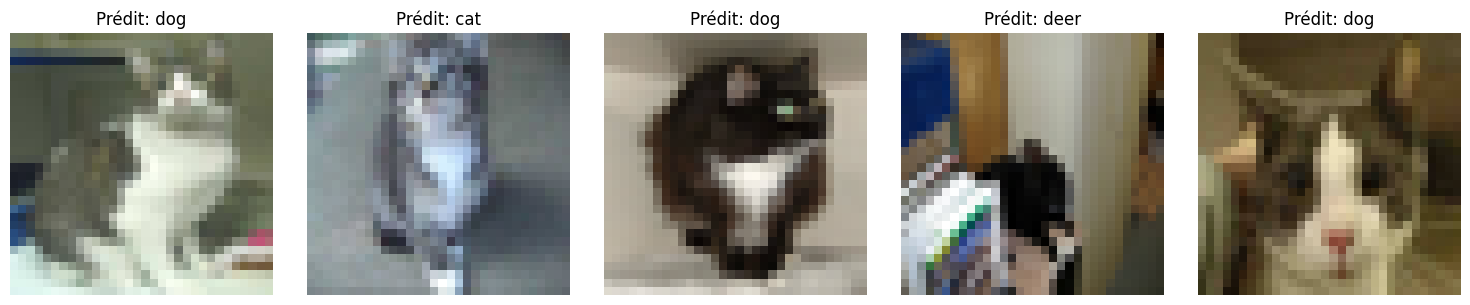

In [ ]:
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# liste d'images de chats à tester
cat_urls = [
    "http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2024.jpg",
    "http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2082.jpg",
    "http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2100.jpg",
    "http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2150.jpg",
    "http://raphael.fournier-sniehotta.fr/files/dcrn/images/cats-dogs-val/cats/cat.2200.jpg"
]

plt.figure(figsize=(15, 3))
for i, url in enumerate(cat_urls):
    img_data = requests.get(url).content
    with open('temp.jpg', 'wb') as f:
        f.write(img_data)

    image = Image.open('temp.jpg')
    image = image.resize((32, 32))
    img = np.array(image) / 255
    imgs = np.expand_dims(img, axis=0)

    predictions = model.predict(imgs, verbose=0)
    predicted_class = classes[np.argmax(predictions)]

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Prédit: {predicted_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

C'est un taux de réussite de 20%, encore pire que l'accuracy globale de 60%. Ça s'explique par :

Le modèle confond souvent chats et chiens car ils se ressemblent (fourrure, forme)
Les images externes sont différentes de celles de CIFAR-10 (fond, angle, qualité)
La compression en 32×32 pixels fait perdre beaucoup de détails. Pour mieux distinguer chats et chiens, il faudrait une architecture plus profonde ou du transfer learning avec un modèle pré-entraîné.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Input
from keras.optimizers import Adam
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Charger les données
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Modèle amélioré avec plus de couches convolutives
model = Sequential()
model.add(Input(shape=(32, 32, 3)))

# Bloc 1
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Bloc 2
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Bloc 3
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Couches denses
model.add(Flatten())
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(10))
model.add(Activation('softmax'))

model.summary()

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# Compilation et entraînement
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

history = model.fit(datagen.flow(X_train, Y_train, batch_size=128),
                    epochs=20,
                    validation_data=(X_test, Y_test),
                    verbose=1)

score = model.evaluate(X_test, Y_test, verbose=0)
print(f"\nTest accuracy: {score[1]*100:.2f}%")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 8, 8, 128)      │             

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.3320 - loss: 1.9602 - val_accuracy: 0.3518 - val_loss: 1.9030
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 539s 1s/step - accuracy: 0.5417 - loss: 1.2756 - val_accuracy: 0.5330 - val_loss: 1.3949
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.6390 - loss: 1.0131 - val_accuracy: 0.6796 - val_loss: 0.9290
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 526s 1s/step - accuracy: 0.6773 - loss: 0.9185 - val_accuracy: 0.6806 - val_loss: 0.9258
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.7026 - loss: 0.8465 - val_accuracy: 0.7278 - val_loss: 0.7934
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.7188 - loss: 0.8020 - val_accuracy: 0.7443 - val_loss: 0.7225
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.7370 - loss: 0.7498 - val_accuracy: 0.7374 - val_loss: 0.7698
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 540s 1s/step - accuracy: 0.7474 - loss: 0.7183 - val_accu

J'ai ajouté ce modèle plus complexe pour essayer d'améliorer les résultats. J'ai cherché sur internet et j'ai trouvé que pour CIFAR-10 il fallait plus de couches de convolution. J'ai aussi vu que BatchNormalization aide à stabiliser l'apprentissage et que la data augmentation permet d'avoir plus de variété dans les images sans en rajouter vraiment.